Решить задачу классификации изображений с помощью многослойного персептрона:
1. Сравнить время обучения на CPU и GPU. 
1. Построить графики ошибки (loss) на train/test подвыборке.
2. Построить графики точности (accuracy) на train/test подвыборке.
3. Оценить качество обучения.
4. Происходит ли переобучение?
5. Происходит ли паралич сети?
6. Добавить early stopping.

In [1]:
import torch
import random
import numpy as np

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.backends.cudnn.deterministic = True

In [2]:
import torchvision.datasets
MNIST_train = torchvision.datasets.MNIST('./', download=False, train=True)
MNIST_test = torchvision.datasets.MNIST('./', download=False, train=False)

In [3]:
X_train = MNIST_train.data
y_train = MNIST_train.targets
X_test = MNIST_test.data
y_test = MNIST_test.targets

In [4]:
X_train.dtype, y_train.dtype

(torch.uint8, torch.int64)

In [5]:
X_train = X_train.float()
X_test = X_test.float()

In [6]:
X_train.shape, X_test.shape

(torch.Size([60000, 28, 28]), torch.Size([10000, 28, 28]))

In [7]:
y_train.shape, y_test.shape

(torch.Size([60000]), torch.Size([10000]))

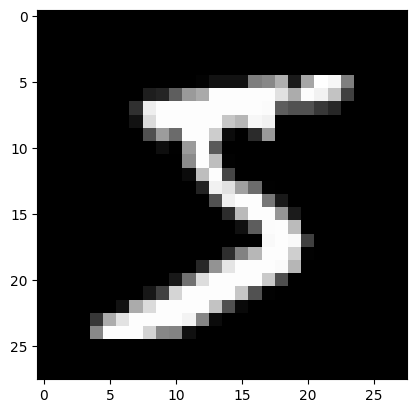

tensor(5)


In [8]:
import matplotlib.pyplot as plt
plt.imshow(X_train[0, :, :], cmap="gray")
plt.show()
print(y_train[0])

Преобразование входных данных

In [9]:
X_train = X_train.reshape([-1, 28 * 28])
X_test = X_test.reshape([-1, 28 * 28])

In [10]:
n_input = 28 * 28
n_output = 10

class MNISTNet(torch.nn.Module):
    def __init__(self, n_hidden_neurons):
        super(MNISTNet, self).__init__()
        self.fc1 = torch.nn.Linear(n_input, n_hidden_neurons)
        self.ac1 = torch.nn.Sigmoid()
        self.fc2 = torch.nn.Linear(n_hidden_neurons, n_output) 
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.ac1(x)
        x = self.fc2(x)
        return x
    
mnist_net = MNISTNet(128)

In [11]:
torch.cuda.is_available()

False

In [12]:
# !nvidia-smi

In [13]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

mnist_net = mnist_net.to(device)

X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)
# list(mnist_net.parameters())

Using device: cpu


In [14]:
loss = torch.nn.CrossEntropyLoss()

# optimizer = torch.optim.SGD(mnist_net.parameters(), lr=1.0e-2)

optimizer = torch.optim.Adam(mnist_net.parameters(), lr=1.0e-4)

In [15]:
import time

batch_size = 256
n_epochs = 50
patience = 5

train_accuracy_history = []
train_loss_history = []
test_accuracy_history = []
test_loss_history = []

best_loss = None
epochs_no_improve = 0

start_time = time.time()

for epoch in range(n_epochs):
    order = np.random.permutation(len(X_train))
    
    for start_index in range(0, len(X_train), batch_size):
        optimizer.zero_grad()
        
        batch_indexes = order[start_index:start_index+batch_size]
        
        X_batch = X_train[batch_indexes]
        y_batch = y_train[batch_indexes]
        
        preds = mnist_net.forward(X_batch) 
        
        loss_value = loss(preds, y_batch)
        loss_value.backward()
        
        optimizer.step()

    with torch.no_grad():
        train_preds = mnist_net(X_train)
        train_loss = loss(train_preds, y_train)
        train_accuracy = (train_preds.argmax(dim=1) == y_train).float().mean()

        test_preds = mnist_net(X_test)
        test_loss = loss(test_preds, y_test)
        test_accuracy = (test_preds.argmax(dim=1) == y_test).float().mean()

    train_loss_history.append(train_loss.item())
    test_loss_history.append(test_loss.item())
    train_accuracy_history.append(train_accuracy.item())
    test_accuracy_history.append(test_accuracy.item())

    if best_loss is None or test_loss.item() < best_loss - 1e-4:
        best_loss = test_loss.item()
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping на эпохе {epoch + 1}")
            break

    print(f"Epoch {epoch + 1}/{n_epochs} | train_acc={train_accuracy.item():.4f} | test_acc={test_accuracy.item():.4f}")

end_time = time.time()
print(f"Training time on {device}: {end_time - start_time:.2f} sec")

Epoch 1/50 | train_acc=0.8443 | test_acc=0.8516
Epoch 2/50 | train_acc=0.8880 | test_acc=0.8919
Epoch 3/50 | train_acc=0.9039 | test_acc=0.9048
Epoch 4/50 | train_acc=0.9137 | test_acc=0.9097
Epoch 5/50 | train_acc=0.9193 | test_acc=0.9161
Epoch 6/50 | train_acc=0.9246 | test_acc=0.9205
Epoch 7/50 | train_acc=0.9308 | test_acc=0.9253
Epoch 8/50 | train_acc=0.9340 | test_acc=0.9283
Epoch 9/50 | train_acc=0.9370 | test_acc=0.9298
Epoch 10/50 | train_acc=0.9406 | test_acc=0.9315
Epoch 11/50 | train_acc=0.9427 | test_acc=0.9342
Epoch 12/50 | train_acc=0.9462 | test_acc=0.9367
Epoch 13/50 | train_acc=0.9485 | test_acc=0.9393
Epoch 14/50 | train_acc=0.9509 | test_acc=0.9408
Epoch 15/50 | train_acc=0.9530 | test_acc=0.9417
Epoch 16/50 | train_acc=0.9559 | test_acc=0.9429
Epoch 17/50 | train_acc=0.9572 | test_acc=0.9433
Epoch 18/50 | train_acc=0.9585 | test_acc=0.9448
Epoch 19/50 | train_acc=0.9604 | test_acc=0.9443
Epoch 20/50 | train_acc=0.9625 | test_acc=0.9449
Epoch 21/50 | train_acc=0.963

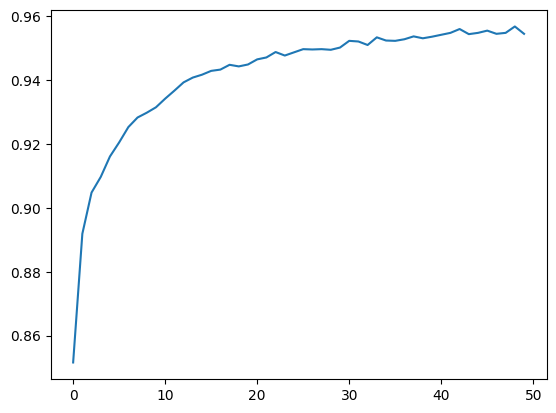

In [16]:
plt.plot(test_accuracy_history)
# plt.plot(train_accuracy_history)

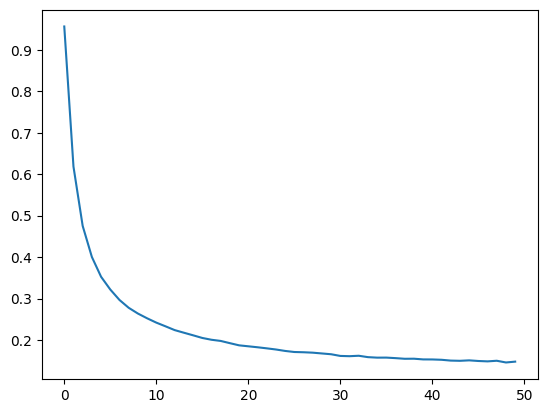

In [17]:
plt.plot(test_loss_history)
# plt.plot(train_loss_history)

# TensorBoard в PyTorch

В машинном обучении важно понимать ключевые показатели, такие как
ошибка модели, и то, как она изменяется во время обучения. Для мониторинга процесса обучения следует сохранять
значения потерь на каждом этапе обучения или точность на каждой эпохе. 


TensorBoard - это инструментарий визуализации для экспериментов с машинным обучением. 
TensorBoard позволяет отслеживать и визуализировать такие показатели, как ошибка и точность,
визуализировать график модели, просматривать гистограммы, отображать изображения и др. 


## Установка

```sh
$ conda install pytorch torchvision -c pytorch
```
или через pip

```sh
$ pip install torch torchvision
```

Для логирования необходимо сначала создать экземпляр класса `SummaryWriter`.

In [18]:
import torch
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter()

/Users/bereznevn/PyCharmMiscProject/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Ключевой аргумент **log_dir** (str) – путь для сохранения. По умолчанию будет сохраняться в  './runs/CURRENT_DATETIME_HOSTNAME'

Применим логирование к нашему скрипту обучения

для записи скалярного значения используется
``add_scalar(tag, scalar_value, global_step=None, walltime=None)``

In [19]:
writer = SummaryWriter(comment="Переработка, ADAM lr0001, батч 256") # будет добавляться в конец названия папки

batch_size = 256

X_test = X_test.to(device)
y_test = y_test.to(device)

for epoch in range(50):
    order = np.random.permutation(len(X_train))
    loss_train = 0.0

    for start_index in range(0, len(X_train), batch_size):
        optimizer.zero_grad()
        
        batch_indexes = order[start_index:start_index+batch_size]
        
        X_batch = X_train[batch_indexes].to(device)
        y_batch = y_train[batch_indexes].to(device)
        
        preds = mnist_net.forward(X_batch) 
        
        loss_value = loss(preds, y_batch)
        loss_value.backward()
        loss_train += loss_value.item()
        optimizer.step()
    
    # средний train loss за эпоху
    writer.add_scalar("Loss/train", loss_train / (len(X_train) / batch_size), epoch)

    # метрики на train
    with torch.no_grad():
        train_preds = mnist_net(X_train)
        train_accuracy = (train_preds.argmax(dim=1) == y_train).float().mean()
        writer.add_scalar("Accuracy/train", train_accuracy.item(), epoch)

    # метрики на test
    test_preds = mnist_net.forward(X_test)
    loss_test = loss(test_preds, y_test)
    writer.add_scalar("Loss/test", loss_test.item(), epoch)

    accuracy_test = (test_preds.argmax(dim=1) == y_test).float().mean()
    writer.add_scalar("Accuracy/test", accuracy_test.item(), epoch)
    print(f"Epoch {epoch + 1}: test_acc={accuracy_test.item():.4f}")

writer.flush()

Epoch 1: test_acc=0.9570
Epoch 2: test_acc=0.9572
Epoch 3: test_acc=0.9564
Epoch 4: test_acc=0.9561
Epoch 5: test_acc=0.9569
Epoch 6: test_acc=0.9566
Epoch 7: test_acc=0.9575
Epoch 8: test_acc=0.9559
Epoch 9: test_acc=0.9569
Epoch 10: test_acc=0.9566
Epoch 11: test_acc=0.9571
Epoch 12: test_acc=0.9570
Epoch 13: test_acc=0.9580
Epoch 14: test_acc=0.9587
Epoch 15: test_acc=0.9577
Epoch 16: test_acc=0.9572
Epoch 17: test_acc=0.9583
Epoch 18: test_acc=0.9582
Epoch 19: test_acc=0.9591
Epoch 20: test_acc=0.9568
Epoch 21: test_acc=0.9581
Epoch 22: test_acc=0.9599
Epoch 23: test_acc=0.9585
Epoch 24: test_acc=0.9580
Epoch 25: test_acc=0.9589
Epoch 26: test_acc=0.9602
Epoch 27: test_acc=0.9588
Epoch 28: test_acc=0.9591
Epoch 29: test_acc=0.9583
Epoch 30: test_acc=0.9590
Epoch 31: test_acc=0.9595
Epoch 32: test_acc=0.9600
Epoch 33: test_acc=0.9600
Epoch 34: test_acc=0.9610
Epoch 35: test_acc=0.9589
Epoch 36: test_acc=0.9591
Epoch 37: test_acc=0.9601
Epoch 38: test_acc=0.9600
Epoch 39: test_acc=0.

In [20]:
writer.flush()

In [21]:
writer.close()

# Визуализация

доступно через web-интерфейс по адресу http://127.0.0.1:6006

In [22]:
%reload_ext tensorboard

In [23]:
%load_ext tensorboard
%tensorboard --logdir runs

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


подробнее о Tensorboard https://pytorch.org/docs/stable/tensorboard.html